## Load Real Data and Pre-trained Models

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
from tensorflow.keras.models import load_model

from sklearn.preprocessing import MinMaxScaler

# Load real financial data
data = pd.read_csv('../data/raw/sp500.csv', index_col='Date', parse_dates=True)
data = data.apply(pd.to_numeric, errors='coerce')
close_prices = data['Close']
log_returns = np.log(close_prices / close_prices.shift(1)).dropna()
log_returns_array = log_returns.values.reshape(-1, 1)

# Normalize again for consistent scaling
scaler = MinMaxScaler()
log_returns_scaled = scaler.fit_transform(log_returns_array)

print(f"Real data shape (log returns scaled): {log_returns_scaled.shape}")

# Load ARIMA model
arima_model = joblib.load('../models/arima_model.pkl')
print("ARIMA model loaded.")

# Load GARCH model
garch_model = joblib.load('../models/garch_model.pkl')
print("GARCH model loaded.")

# Load TimeGAN models
embedder = load_model('../models/timegan_embedder_orig.h5')
recovery = load_model('../models/timegan_recovery_orig.h5')
#generator = load_model('../models/timegan_generator_orig.h5')
generator = load_model('../models/wavenet_generator.keras')
discriminator = load_model('../models/timegan_discriminator_orig.h5')
print("TimeGAN models loaded.")

Real data shape (log returns scaled): (6036, 1)
ARIMA model loaded.
GARCH model loaded.


TimeGAN models loaded.


## Generate Synthetic Data for Evaluation

In [ ]:
import numpy as np

# ------ Generate Synthetic Data with TimeGAN -----

n_samples = 100  # Number of sequences
sequence_length = 24
z_dim = 32  # Same as during training

# Random noise for Generator
Z_synthetic = np.random.uniform(0, 1, size=(n_samples, sequence_length, z_dim)).astype(np.float32)

# Generate synthetic sequences
synthetic_timegan = generator.predict(Z_synthetic)

# Reshape (n_samples * sequence_length, 1)
synthetic_timegan_flat = synthetic_timegan.reshape(-1, 1)

# Rescale back to original scale
synthetic_timegan_rescaled = scaler.inverse_transform(synthetic_timegan_flat)

print(f"Generated {n_samples} synthetic sequences using TimeGAN.")


# ----- Generate Simulated Synthetic Data for VAE -----

# Here we simulate synthetic sequences similar to VAE outputs
synthetic_vae_simulated = np.random.normal(
    loc=np.mean(log_returns_scaled), 
    scale=np.std(log_returns_scaled), 
    size=(n_samples * sequence_length, 1)
)

# Rescale back to original log-return scale
synthetic_vae_rescaled = scaler.inverse_transform(synthetic_vae_simulated)

print(f"Generated {n_samples} synthetic sequences using Simulated VAE.")

# ----- Prepare Real Data -----

# Reshape real data to match format
real_data_prepared = log_returns_array[:n_samples * sequence_length]

print(f"Prepared real data with shape: {real_data_prepared.shape}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Generated 100 synthetic sequences using TimeGAN.
Generated 100 synthetic sequences using Simulated VAE.
Prepared real data with shape: (2400, 1)


## PCA Visualization of Real vs TimeGAN vs VAE

New real data shape: (100, 24)
New combined data shape: (300, 24)


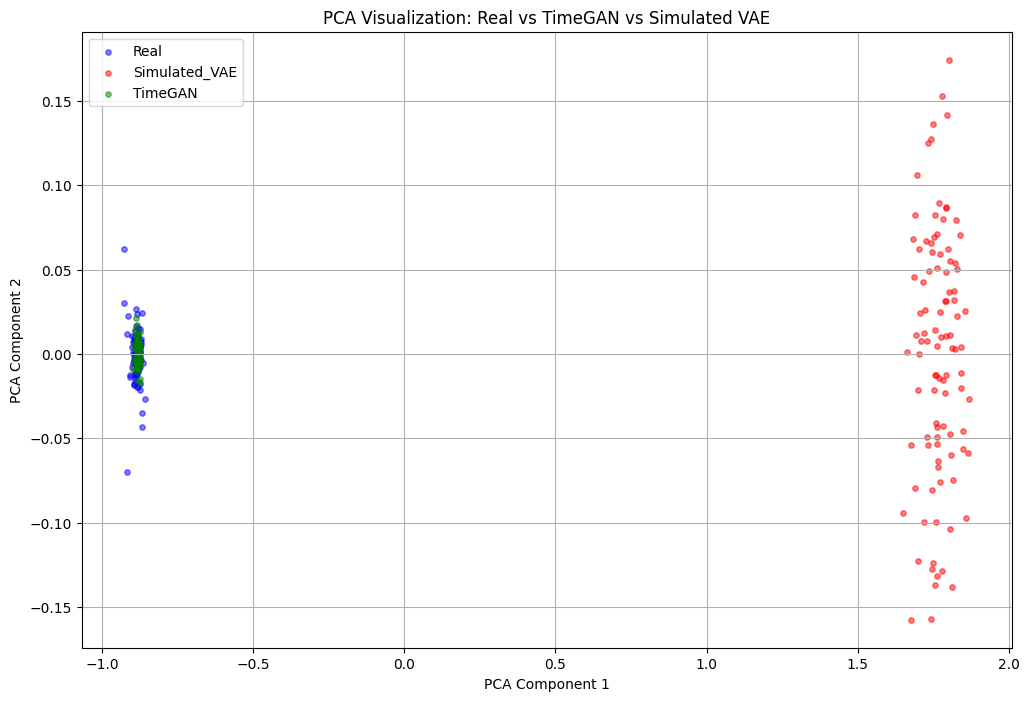

In [20]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 1. Reshape all datasets into sequences
sequence_length = 24  # Same as used during generation

# Reshape real data
real_data_seq = real_data_prepared.reshape(-1, sequence_length)
print(f"New real data shape: {real_data_seq.shape}")
# Reshape synthetic TimeGAN data
synthetic_timegan_seq = synthetic_timegan_rescaled.reshape(-1, sequence_length)

# Reshape synthetic VAE data
synthetic_vae_seq = synthetic_vae_simulated.reshape(-1, sequence_length)

# Combine datasets vertically
combined_data = np.vstack([
    real_data_seq,
    synthetic_timegan_seq,
    synthetic_vae_seq
])

# Create labels
labels = (
    ["Real"] * real_data_seq.shape[0] +
    ["TimeGAN"] * synthetic_timegan_seq.shape[0] +
    ["Simulated_VAE"] * synthetic_vae_seq.shape[0]
)

print(f"New combined data shape: {combined_data.shape}")

# 2. Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(combined_data)

# 3. Prepare color mapping
color_map = {
    "Real": "blue",
    "TimeGAN": "green",
    "Simulated_VAE": "red"
}

# 4. Plot PCA results
plt.figure(figsize=(12,8))
for label in np.unique(labels):
    indices = np.array(labels) == label
    plt.scatter(
        pca_result[indices, 0],
        pca_result[indices, 1],
        alpha=0.5,
        label=label,
        s=15,
        c=color_map[label]
    )

plt.title('PCA Visualization: Real vs TimeGAN vs Simulated VAE')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True)
plt.show()

## Compute MMD Distance between Real and Synthetic Data

In [21]:
import tensorflow as tf

def compute_mmd(x, y, kernel='rbf', sigma=1.0):
    """Compute the Maximum Mean Discrepancy (MMD) between two samples."""
    
    x = tf.convert_to_tensor(x, dtype=tf.float32)
    y = tf.convert_to_tensor(y, dtype=tf.float32)
    
    if kernel == 'rbf':
        # Gaussian (RBF) kernel
        xx = tf.matmul(x, tf.transpose(x))
        yy = tf.matmul(y, tf.transpose(y))
        xy = tf.matmul(x, tf.transpose(y))
        
        rx = tf.expand_dims(tf.reduce_sum(x * x, axis=1), 0)
        ry = tf.expand_dims(tf.reduce_sum(y * y, axis=1), 0)
        
        Kxx = tf.exp(- (rx - 2 * xx + tf.transpose(rx)) / (2 * sigma ** 2))
        Kyy = tf.exp(- (ry - 2 * yy + tf.transpose(ry)) / (2 * sigma ** 2))
        Kxy = tf.exp(- (rx - 2 * xy + tf.transpose(ry)) / (2 * sigma ** 2))
        
        mmd = tf.reduce_mean(Kxx) + tf.reduce_mean(Kyy) - 2 * tf.reduce_mean(Kxy)
        
        return mmd.numpy()

# Compute MMD between Real and TimeGAN
mmd_timegan = compute_mmd(real_data_seq, synthetic_timegan_seq, sigma=1.0)
print(f"MMD (Real vs TimeGAN): {mmd_timegan:.6f}")

# Compute MMD between Real and Simulated VAE
mmd_vae = compute_mmd(real_data_seq, synthetic_vae_seq, sigma=1.0)
print(f"MMD (Real vs Simulated VAE): {mmd_vae:.6f}")

MMD (Real vs TimeGAN): 0.000062
MMD (Real vs Simulated VAE): 1.875655


## Additional Evaluation Metrics
Fréchet Distance, DTW, Autocorrelation RMSE, and Discriminative Score

In [ ]:
import sys
sys.path.append('..')
from utils.evaluation_metrics import compute_mmd, compute_frechet_distance, compute_dtw_distance

# Reshape to 3D (samples, timesteps, channels) for metrics that need it
real_3d = real_data_seq.reshape(-1, sequence_length, 1)
timegan_3d = synthetic_timegan_seq.reshape(-1, sequence_length, 1)
vae_3d = synthetic_vae_seq.reshape(-1, sequence_length, 1)
mmd_score = compute_mmd(real_data_seq, synthetic_timegan_seq)
print(f"MMD (WaveNet GAN): {mmd_score:.6f}")

# ============================================
# Fréchet Distance
# ============================================
fd_timegan = compute_frechet_distance(real_3d, timegan_3d, per_channel=True)
fd_vae = compute_frechet_distance(real_3d, vae_3d, per_channel=True)

print("\nFréchet Distance (lower = better):")
print(f"  Real vs TimeGAN:       {fd_timegan['overall_fd']:.6f}")
print(f"  Real vs Simulated VAE: {fd_vae['overall_fd']:.6f}")

# ============================================
# DTW (Dynamic Time Warping) Distance
# ============================================
# Use subset for DTW (computationally expensive)
n_dtw = min(50, len(real_3d))
dtw_timegan = compute_dtw_distance(real_3d[:n_dtw], timegan_3d[:n_dtw])
dtw_vae = compute_dtw_distance(real_3d[:n_dtw], vae_3d[:n_dtw])

print(f"\nDTW Distance (lower = better, {n_dtw} samples):")
print(f"  Real vs TimeGAN:       {dtw_timegan:.6f}")
print(f"  Real vs Simulated VAE: {dtw_vae:.6f}")

# ============================================
# Autocorrelation Comparison
# ============================================
def compute_autocorrelation(data, max_lag=10):
    flat = data.flatten()
    mean, var = np.mean(flat), np.var(flat)
    return np.array([
        np.mean((flat[:-lag] - mean) * (flat[lag:] - mean)) / (var + 1e-8)
        for lag in range(1, max_lag + 1)
    ])

real_acf = compute_autocorrelation(real_data_seq)
timegan_acf = compute_autocorrelation(synthetic_timegan_seq)
vae_acf = compute_autocorrelation(synthetic_vae_seq)

acf_rmse_timegan = np.sqrt(np.mean((real_acf - timegan_acf)**2))
acf_rmse_vae = np.sqrt(np.mean((real_acf - vae_acf)**2))

# Squared returns (volatility clustering)
real_sq_acf = compute_autocorrelation(real_data_seq**2)
timegan_sq_acf = compute_autocorrelation(synthetic_timegan_seq**2)
vae_sq_acf = compute_autocorrelation(synthetic_vae_seq**2)

sq_acf_rmse_timegan = np.sqrt(np.mean((real_sq_acf - timegan_sq_acf)**2))
sq_acf_rmse_vae = np.sqrt(np.mean((real_sq_acf - vae_sq_acf)**2))

print(f"\nAutocorrelation RMSE — Returns (lower = better):")
print(f"  Real vs TimeGAN:       {acf_rmse_timegan:.6f}")
print(f"  Real vs Simulated VAE: {acf_rmse_vae:.6f}")
print(f"\nAutocorrelation RMSE — Squared Returns / Volatility Clustering (lower = better):")
print(f"  Real vs TimeGAN:       {sq_acf_rmse_timegan:.6f}")
print(f"  Real vs Simulated VAE: {sq_acf_rmse_vae:.6f}")

# ============================================
# Discriminative Score
# ============================================
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

def discriminative_score(real_2d, synth_2d, label="Synthetic"):
    X = np.vstack([real_2d, synth_2d])
    y = np.concatenate([np.ones(len(real_2d)), np.zeros(len(synth_2d))])
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    clf = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    score = abs(0.5 - acc)
    print(f"  Real vs {label:<15s} — Accuracy: {acc:.4f}, Score: {score:.4f}")
    return acc, score

print(f"\nDiscriminative Score (accuracy closer to 0.5 = better, score closer to 0 = better):")
acc_tg, ds_tg = discriminative_score(real_data_seq, synthetic_timegan_seq, "TimeGAN")
acc_vae, ds_vae = discriminative_score(real_data_seq, synthetic_vae_seq, "Simulated VAE")

# ============================================
# Summary Table
# ============================================
print("\n" + "=" * 70)
print("EVALUATION SUMMARY")
print("=" * 70)
print(f"{'Metric':<45} {'TimeGAN':>10} {'Sim. VAE':>10}")
print("-" * 70)
print(f"{'MMD (lower=better)':<45} {mmd_timegan:>10.6f} {mmd_vae:>10.6f}")
print(f"{'Fréchet Distance (lower=better)':<45} {fd_timegan['overall_fd']:>10.6f} {fd_vae['overall_fd']:>10.6f}")
print(f"{'DTW Distance (lower=better)':<45} {dtw_timegan:>10.4f} {dtw_vae:>10.4f}")
print(f"{'ACF RMSE — returns (lower=better)':<45} {acf_rmse_timegan:>10.6f} {acf_rmse_vae:>10.6f}")
print(f"{'ACF RMSE — sq. returns (lower=better)':<45} {sq_acf_rmse_timegan:>10.6f} {sq_acf_rmse_vae:>10.6f}")
print(f"{'Discriminative Score (closer to 0=better)':<45} {ds_tg:>10.4f} {ds_vae:>10.4f}")
print("=" * 70)

MMD (WaveNet GAN): 0.000062

Fréchet Distance (lower = better):
  Real vs TimeGAN:       0.000057
  Real vs Simulated VAE: 0.294460

DTW Distance (lower = better, 50 samples):
  Real vs TimeGAN:       17.898143
  Real vs Simulated VAE: 18.178655

Autocorrelation RMSE — Returns (lower = better):
  Real vs TimeGAN:       0.046476
  Real vs Simulated VAE: 0.060411

Autocorrelation RMSE — Squared Returns / Volatility Clustering (lower = better):
  Real vs TimeGAN:       0.223556
  Real vs Simulated VAE: 0.286765

Discriminative Score (accuracy closer to 0.5 = better, score closer to 0 = better):
  Real vs TimeGAN         — Accuracy: 0.5000, Score: 0.0000
  Real vs Simulated VAE   — Accuracy: 1.0000, Score: 0.5000

EVALUATION SUMMARY
Metric                                           TimeGAN   Sim. VAE
----------------------------------------------------------------------
MMD (lower=better)                              0.000062   1.875655
Fréchet Distance (lower=better)                 0.0000

: 

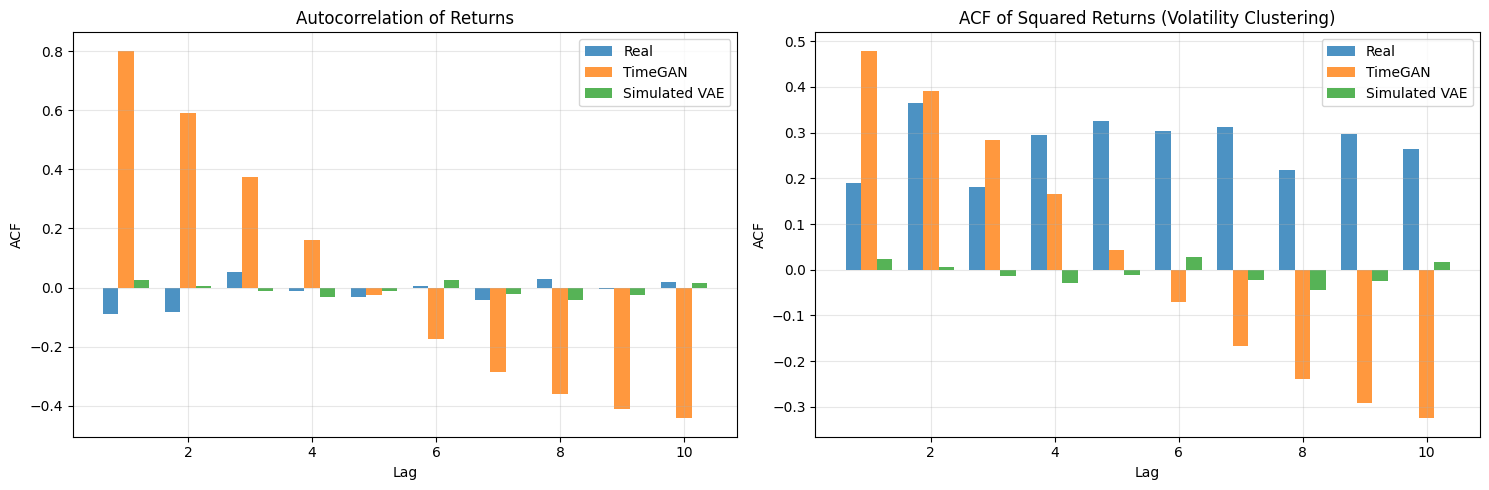

: 

In [ ]:
# ---- Autocorrelation Plots ----
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
lags = np.arange(1, 11)
w = 0.25

axes[0].bar(lags - w, real_acf, width=w, label='Real', alpha=0.8)
axes[0].bar(lags, timegan_acf, width=w, label='TimeGAN', alpha=0.8)
axes[0].bar(lags + w, vae_acf, width=w, label='Simulated VAE', alpha=0.8)
axes[0].set_title('Autocorrelation of Returns')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('ACF')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(lags - w, real_sq_acf, width=w, label='Real', alpha=0.8)
axes[1].bar(lags, timegan_sq_acf, width=w, label='TimeGAN', alpha=0.8)
axes[1].bar(lags + w, vae_sq_acf, width=w, label='Simulated VAE', alpha=0.8)
axes[1].set_title('ACF of Squared Returns (Volatility Clustering)')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('ACF')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Save Synthetic Data for Use Cases

In [14]:
# Resave TimeGAN synthetic data
np.save('../data/processed/synthetic_timegan.npy', synthetic_timegan_rescaled)

# Resave Simulated VAE synthetic data
np.save('../data/processed/simulated_vae.npy', synthetic_vae_simulated)

print("Synthetic data saved successfully in /data/processed/")

Synthetic data saved successfully in /data/processed/
